# Mouth Classification using CNN

## Objective

Train a Convolutional Neural Network (CNN) to classify mouth images into three classes.

- Mouth Closed
- Talking
- Yawning

Unlike the original implementation, this notebook uses a preprocessed mouth dataset.

MediaPipe preprocessing is performed only once in a separate notebook, allowing this notebook to focus solely on CNN training.

---

## Workflow

Preprocessed Dataset

↓

DataLoader

↓

CNN

↓

Training

↓

Best Model

↓

Evaluation

In [ ]:
import torch
from pathlib import Path

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
import sys
print(sys.executable)

c:\Users\Omswaroop\OneDrive\Desktop\New folder\.venv-1\Scripts\python.exe


In [3]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import random
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "frames" / "mouth_dataset"

IMAGE_SIZE = 128

BATCH_SIZE = 128

LEARNING_RATE = 1e-3

EPOCHS = 50

NUM_CLASSES = 3

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

print("Configuration Loaded")

PyTorch Version : 2.11.0+cu128
CUDA Available : True
CUDA Version : 12.8
Running Device : cuda
GPU : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM : 4.0 GB


In [5]:
# ============================================================
# CONFIGURATION
# ============================================================

DATASET_ROOT = r"C:\Users\Omswaroop\OneDrive\Desktop\New folder\frames\mouth_dataset"

IMAGE_SIZE = 128

BATCH_SIZE = 128

LEARNING_RATE = 1e-3

EPOCHS = 50

NUM_CLASSES = 3

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

print("Configuration Loaded")

Configuration Loaded


In [6]:
# ============================================================
# SCAN PREPROCESSED DATASET
# ============================================================

CLASSES = {

    "mouth_closed": 0,

    "talking": 1,

    "yawning": 2

}

image_paths = []

labels = []

for class_name, label in CLASSES.items():

    folder = os.path.join(

        DATASET_ROOT,

        class_name

    )

    if not os.path.exists(folder):

        raise FileNotFoundError(

            f"Folder not found:\n{folder}"

        )

    files = [

        file for file in os.listdir(folder)

        if file.lower().endswith(

            (".jpg", ".jpeg", ".png")

        )

    ]

    for file in files:

        image_paths.append(

            os.path.join(folder, file)

        )

        labels.append(label)

print("=" * 60)

print(f"Total Images : {len(image_paths):,}")

print(f"Total Labels : {len(labels):,}")

print("=" * 60)

Total Images : 268,166
Total Labels : 268,166


In [7]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_paths, temp_paths, train_labels, temp_labels = train_test_split(

    image_paths,

    labels,

    test_size=0.20,

    random_state=SEED,

    stratify=labels

)

val_paths, test_paths, val_labels, test_labels = train_test_split(

    temp_paths,

    temp_labels,

    test_size=0.50,

    random_state=SEED,

    stratify=temp_labels

)

print("Training Images   :", len(train_paths))

print("Validation Images :", len(val_paths))

print("Testing Images    :", len(test_paths))

Training Images   : 214532
Validation Images : 26817
Testing Images    : 26817


In [8]:
# ============================================================
# FAST MOUTH DATASET
# ============================================================

import cv2

class MouthDataset(Dataset):

    def __init__(
        self,
        image_paths,
        labels
    ):

        self.image_paths = image_paths
        self.labels = labels

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        image = cv2.imread(
            self.image_paths[idx],
            cv2.IMREAD_GRAYSCALE
        )

        if image is None:

            raise RuntimeError(
                f"Could not read image:\n"
                f"{self.image_paths[idx]}"
            )

        # Convert NumPy array to PyTorch tensor
        image = torch.from_numpy(
            image
        ).unsqueeze(0).float()

        # Convert pixel values from [0, 255] to [0, 1]
        image = image / 255.0

        # Normalize to approximately [-1, 1]
        image = (image - 0.5) / 0.5

        label = self.labels[idx]

        return image, label

In [9]:
# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = MouthDataset(
    train_paths,
    train_labels
)

val_dataset = MouthDataset(
    val_paths,
    val_labels
)

test_dataset = MouthDataset(
    test_paths,
    test_labels
)

print("Datasets Created Successfully")

Datasets Created Successfully


In [10]:
# ============================================================
# OPTIMIZED DATALOADERS - BATCH SIZE 256
# ============================================================

BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("DataLoaders Ready")
print("Batch Size :", BATCH_SIZE)
print("Workers    : 0")
print("Pin Memory : True")

DataLoaders Ready
Batch Size : 256
Workers    : 0
Pin Memory : True


In [11]:
# ============================================================
# TEST DATALOADER SPEED
# ============================================================

start = time.time()

images, labels = next(iter(train_loader))

elapsed = time.time() - start

print("Image Shape :", images.shape)
print("Label Shape :", labels.shape)
print(f"Loading Time : {elapsed:.3f} seconds")

Image Shape : torch.Size([256, 1, 128, 128])
Label Shape : torch.Size([256])
Loading Time : 0.212 seconds


In [12]:
# ============================================================
# CUDA MIXED PRECISION SETUP
# ============================================================

if torch.cuda.is_available():

    scaler = torch.amp.GradScaler("cuda")

    print("CUDA AMP enabled")

else:

    scaler = None

    print("CUDA AMP unavailable")

CUDA AMP enabled


In [13]:
# ============================================================
# CNN MODEL
# ============================================================

class CustomCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(

                1,

                32,

                kernel_size=3,

                padding=1

            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(

                32,

                64,

                kernel_size=3,

                padding=1

            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(

                64,

                128,

                kernel_size=3,

                padding=1

            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(

                128 * 16 * 16,

                256

            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(

                256,

                NUM_CLASSES

            )

        )

    def forward(

        self,

        x

    ):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [14]:
# ============================================================
# INITIALIZE MODEL
# ============================================================

model = CustomCNN().to(device)

print("=" * 60)
print(model)
print("=" * 60)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

CustomCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropo

In [15]:
# ============================================================
# LOSS FUNCTION & OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=1e-5

)

print("Loss Function : CrossEntropyLoss")

print("Optimizer     : Adam")

print(f"Learning Rate : {LEARNING_RATE}")

Loss Function : CrossEntropyLoss
Optimizer     : Adam
Learning Rate : 0.001


In [16]:
# ============================================================
# ACCURACY FUNCTION
# ============================================================

def accuracy(outputs, labels):

    predicted = outputs.argmax(dim=1)

    correct = (

        predicted == labels

    ).sum().item()

    return correct

In [17]:
# ============================================================
# OPTIMIZED GPU TRAINING - ONE EPOCH
# ============================================================

def train_one_epoch():

    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    loop = tqdm(
        train_loader,
        desc="Training"
    )

    for images, labels in loop:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # Mixed Precision Forward Pass
        # ----------------------------------------------------

        if device.type == "cuda":

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            # ------------------------------------------------
            # Scaled Backpropagation
            # ------------------------------------------------

            scaler.scale(loss).backward()

            scaler.step(optimizer)

            scaler.update()

        else:

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        running_loss += loss.item()

        running_correct += accuracy(
            outputs,
            labels
        )

        total += labels.size(0)

        current_acc = (
            100.0 *
            running_correct /
            total
        )

        loop.set_postfix(
            Loss=f"{loss.item():.4f}",
            Acc=f"{current_acc:.2f}%"
        )

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    epoch_acc = (
        100.0 *
        running_correct /
        total
    )

    return epoch_loss, epoch_acc

In [18]:
# ============================================================
# OPTIMIZED VALIDATION
# ============================================================

def validate():

    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():

        loop = tqdm(
            val_loader,
            desc="Validation",
            leave=False
        )

        for images, labels in loop:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            if device.type == "cuda":

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                ):

                    outputs = model(images)
                    loss = criterion(
                        outputs,
                        labels
                    )

            else:

                outputs = model(images)
                loss = criterion(
                    outputs,
                    labels
                )

            running_loss += loss.item()

            running_correct += accuracy(
                outputs,
                labels
            )

            total += labels.size(0)

            loop.set_postfix(
                Loss=f"{loss.item():.4f}",
                Acc=f"{100 * running_correct / total:.2f}%"
            )

    epoch_loss = running_loss / len(val_loader)

    epoch_acc = (
        100 * running_correct / total
    )

    return epoch_loss, epoch_acc

In [ ]:
# ============================================================
# TRAIN MODEL
# ============================================================

train_losses = []

val_losses = []

train_accs = []

val_accs = []

best_acc = float("-inf")

BEST_MODEL_PATH = PROJECT_ROOT / "models" / "mouth_cnn_best.pth"

training_start = time.time()

for epoch in range(EPOCHS):

    print("\n" + "=" * 70)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print("=" * 70)

    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch()

    val_loss, val_acc = validate()

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    train_accs.append(train_acc)

    val_accs.append(val_acc)

    print(f"\nTrain Loss : {train_loss:.4f}")

    print(f"Train Acc  : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Val Acc    : {val_acc:.2f}%")

    print(f"Epoch Time : {(time.time()-epoch_start)/60:.2f} min")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(

            model.state_dict(),

            BEST_MODEL_PATH

        )

        print("✓ Best model updated.")

print("\nTraining Completed.")

print(f"Best Validation Accuracy : {best_acc:.2f}%")

print(f"Total Training Time : {(time.time()-training_start)/3600:.2f} hours")


Epoch 1/50


Training: 100%|██████████| 838/838 [04:39<00:00,  3.00it/s, Acc=94.37%, Loss=0.2047]



Train Loss : 0.2800
Train Acc  : 94.37%
Val Loss   : 0.1575
Val Acc    : 95.10%
Epoch Time : 5.15 min
✓ Best model updated.

Epoch 2/50


Training: 100%|██████████| 838/838 [03:46<00:00,  3.70it/s, Acc=94.99%, Loss=0.1701]



Train Loss : 0.1697
Train Acc  : 94.99%
Val Loss   : 0.1492
Val Acc    : 95.22%
Epoch Time : 4.03 min
✓ Best model updated.

Epoch 3/50


...


Train Loss : 0.0307
Train Acc  : 98.82%
Val Loss   : 0.1472
Val Acc    : 96.87%
Epoch Time : 6.38 min

Epoch 49/50


Training: 100%|██████████| 838/838 [04:47<00:00,  2.91it/s, Acc=98.87%, Loss=0.0370]



Train Loss : 0.0294
Train Acc  : 98.87%
Val Loss   : 0.1732
Val Acc    : 96.83%
Epoch Time : 5.21 min

Epoch 50/50


Training: 100%|██████████| 838/838 [05:05<00:00,  2.74it/s, Acc=98.89%, Loss=0.0149]
                                                                                      


Train Loss : 0.0287
Train Acc  : 98.89%
Val Loss   : 0.1317
Val Acc    : 96.71%
Epoch Time : 5.53 min

Training Completed.
Best Validation Accuracy : 97.08%
Total Training Time : 3.40 hours


In [20]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

model.load_state_dict(

    torch.load(

        BEST_MODEL_PATH,

        map_location=device

    )

)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [22]:
# ============================================================
# TEST MODEL
# ============================================================

running_correct = 0

total = 0

predictions = []

ground_truth = []

loop = tqdm(

    test_loader,

    desc="Testing",

    leave=False

)

with torch.no_grad():

    for images, labels in loop:

        images = images.to(

            device,

            non_blocking=True

        )

        labels = labels.to(

            device,

            non_blocking=True

        )

        outputs = model(images)

        predicted = outputs.argmax(dim=1)

        running_correct += (

            predicted == labels

        ).sum().item()

        total += labels.size(0)

        predictions.extend(

            predicted.cpu().numpy()

        )

        ground_truth.extend(

            labels.cpu().numpy()

        )

test_acc = 100 * running_correct / total

print("\n" + "=" * 60)

print(f"Test Accuracy : {test_acc:.2f}%")

print("=" * 60)


Test Accuracy : 97.03%


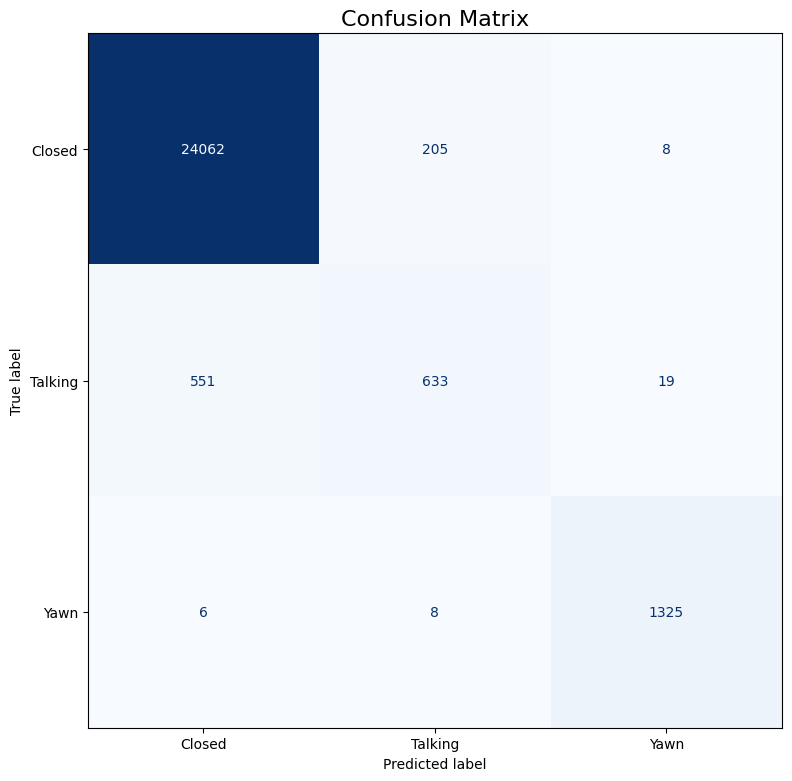

In [23]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

CLASS_NAMES = [

    "Closed",

    "Talking",

    "Yawn"

]

cm = confusion_matrix(

    ground_truth,

    predictions

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=CLASS_NAMES

)

fig, ax = plt.subplots(

    figsize=(8, 8)

)

disp.plot(

    cmap="Blues",

    ax=ax,

    colorbar=False,

    values_format="d"

)

plt.title(

    "Confusion Matrix",

    fontsize=16

)

plt.tight_layout()

plt.show()

In [24]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)

print("Classification Report")

print("=" * 60)

print(

    classification_report(

        ground_truth,

        predictions,

        target_names=CLASS_NAMES,

        digits=4

    )

)


Classification Report
              precision    recall  f1-score   support

      Closed     0.9774    0.9912    0.9843     24275
     Talking     0.7482    0.5262    0.6179      1203
        Yawn     0.9800    0.9895    0.9848      1339

    accuracy                         0.9703     26817
   macro avg     0.9019    0.8357    0.8623     26817
weighted avg     0.9672    0.9703    0.9678     26817



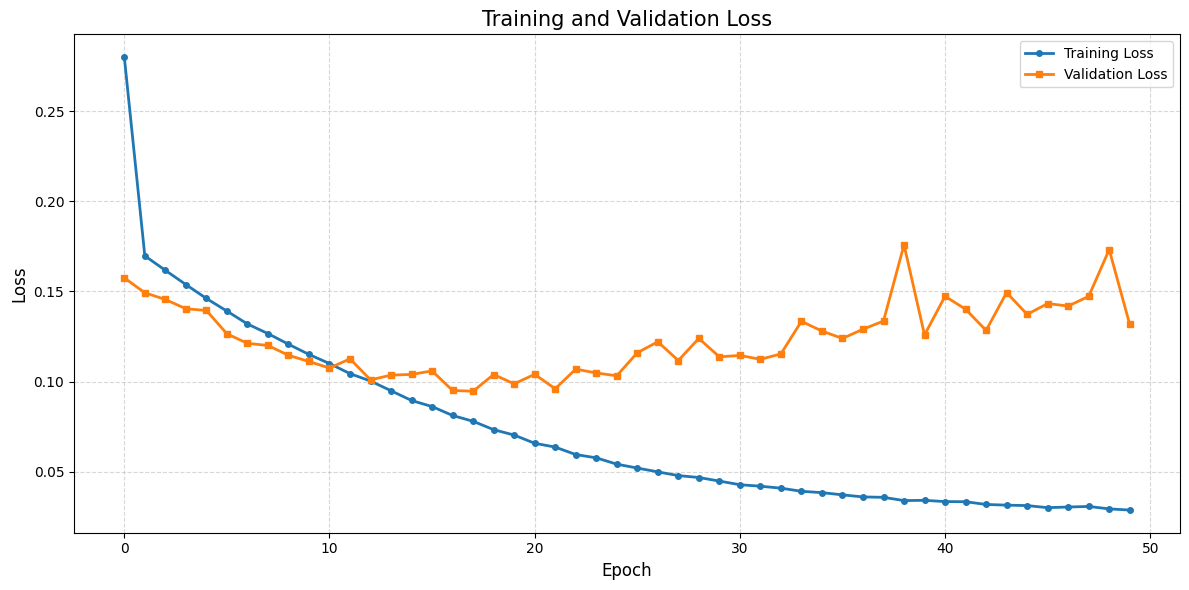

In [25]:
# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(

    figsize=(12,6)

)

plt.plot(

    train_losses,

    label="Training Loss",

    linewidth=2,

    marker="o",

    markersize=4

)

plt.plot(

    val_losses,

    label="Validation Loss",

    linewidth=2,

    marker="s",

    markersize=4

)

plt.xlabel(

    "Epoch",

    fontsize=12

)

plt.ylabel(

    "Loss",

    fontsize=12

)

plt.title(

    "Training and Validation Loss",

    fontsize=15

)

plt.grid(

    linestyle="--",

    alpha=0.5

)

plt.legend()

plt.tight_layout()

plt.show()

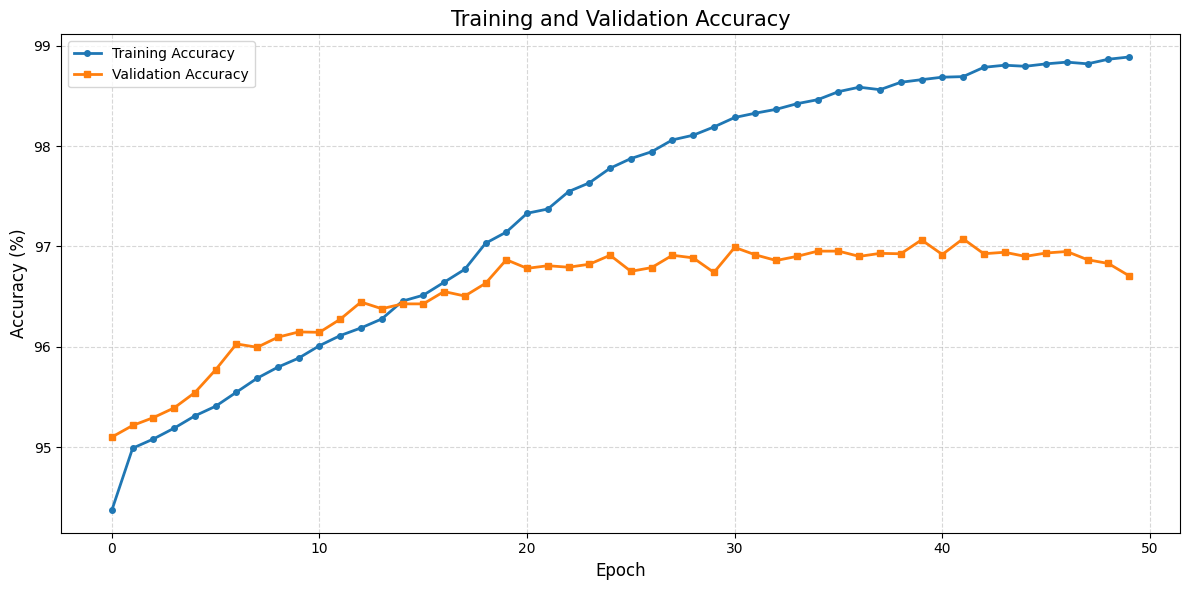

In [26]:
# ============================================================
# ACCURACY CURVE
# ============================================================

plt.figure(

    figsize=(12,6)

)

plt.plot(

    train_accs,

    label="Training Accuracy",

    linewidth=2,

    marker="o",

    markersize=4

)

plt.plot(

    val_accs,

    label="Validation Accuracy",

    linewidth=2,

    marker="s",

    markersize=4

)

plt.xlabel(

    "Epoch",

    fontsize=12

)

plt.ylabel(

    "Accuracy (%)",

    fontsize=12

)

plt.title(

    "Training and Validation Accuracy",

    fontsize=15

)

plt.grid(

    linestyle="--",

    alpha=0.5

)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# SAVE COMPLETE MODEL
# ============================================================

COMPLETE_MODEL_PATH = PROJECT_ROOT / "models" / "archive" / "models/archive/mouth_cnn_complete.pth"

torch.save(

    model,

    COMPLETE_MODEL_PATH

)

print("\n✓ Complete model saved successfully.")

print(f"Location : {COMPLETE_MODEL_PATH}")


✓ Complete model saved successfully.
Location : models/archive/mouth_cnn_complete.pth


In [ ]:
# ============================================================
# SAVE MODEL WEIGHTS
# ============================================================

WEIGHTS_PATH = PROJECT_ROOT / "models" / "archive" / "models/archive/mouth_cnn_weights.pth"

torch.save(

    model.state_dict(),

    WEIGHTS_PATH

)

print("\n✓ Model weights saved successfully.")

print(f"Location : {WEIGHTS_PATH}")


✓ Model weights saved successfully.
Location : models/archive/mouth_cnn_weights.pth
